In [1]:
import nltk
import numpy as np
import pandas as pd

In [2]:
from nltk.corpus import sentence_polarity

In [3]:
nltk.download('sentence_polarity')

[nltk_data] Downloading package sentence_polarity to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping corpora/sentence_polarity.zip.


True

In [8]:
all_positive_sentences = sentence_polarity.raw(categories='pos').strip().split('\n')
all_negative_sentences = sentence_polarity.raw(categories='neg').strip().split('\n')

In [9]:
all_positive_sentences[:3]

['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal . ',
 'the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson\'s expanded vision of j . r . r . tolkien\'s middle-earth . ',
 'effective but too-tepid biopic']

In [10]:
len(all_positive_sentences)

5331

In [11]:
len(all_negative_sentences)

5331

In [12]:
test_pos = all_positive_sentences[4000:]
train_pos = all_positive_sentences[:4000]
test_neg = all_negative_sentences[4000:]
train_neg = all_negative_sentences[:4000]

In [13]:
len(train_neg)

4000

In [14]:
len(test_neg)

1331

In [15]:
train_x = train_pos + train_neg
test_x = test_pos + test_neg

train_y = np.append(np.ones(len(train_pos)), np.zeros(len(train_neg)))
test_y = np.append(np.ones(len(test_pos)), np.zeros(len(test_neg)))

In [16]:
len(train_x)

8000

In [17]:
train_x[7890]

'the biggest problem i have ( other than the very sluggish pace ) is we never really see her esther blossom as an actress , even though her talent is supposed to be growing . '

In [24]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
def process_sentence(sentence):
    """Process sentence function.
    Input:
        sentence: a string containing a sentence
    Output:
        sentences_clean: a list of words containing the processed sentence
    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    # remove hyperlinks
    sentence = re.sub(r'https?://[^\s\r\n]+', '', sentence)

    # tokenize sentences
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    sentence_tokens = tokenizer.tokenize(sentence)

    sentences_clean = []
    for word in sentence_tokens:
        if (word not in stopwords_english and  # remove stopwords
            word not in string.punctuation):    # remove punctuation

            stem_word = stemmer.stem(word)  # stemming word
            sentences_clean.append(stem_word)

    return sentences_clean

In [22]:
train_x[0]

'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal . '

In [25]:
process_sentence(train_x[0])

['rock',
 'destin',
 '21st',
 "century'",
 'new',
 'conan',
 'go',
 'make',
 'splash',
 'even',
 'greater',
 'arnold',
 'schwarzenegg',
 'jean-claud',
 'van',
 'damm',
 'steven',
 'segal']

In [26]:
len(train_y)

8000

In [27]:
def build_freqs(sentences, ys):
    """Build frequencies.
    Input:
        sentences: a list of sentences
        ys: an m x 1 array with the sentiment label of each sentence
            (either 0 or 1)
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Convert np array to list since zip needs an iterable.
    # The squeeze is necessary or the list ends up with one element.
    # Also note that this is just a NOP if ys is already a list.
    yslist = np.squeeze(ys).tolist()

    # Start with an empty dictionary and populate it by looping over all sentences
    # and over all processed words in each sentence.
    freqs = {}
    for y, sentence in zip(yslist, sentences):
        for word in process_sentence(sentence):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1

    return freqs

In [28]:
freqs = build_freqs(train_x, train_y)

In [29]:
len(freqs)

17825

In [32]:
freqs[('film', 0)]

543

In [47]:
pos_top = sorted([(w, c) for (w, y), c in freqs.items() if y == 1], key=lambda t: -t[1])
neg_top = sorted([(w, c) for (w, y), c in freqs.items() if y == 0], key=lambda t: -t[1])

In [48]:
print("Слів у позитиві:", len(pos_top))

Слів у позитиві: 8772


In [49]:
print("Слів у негативі:", len(neg_top))

Слів у негативі: 9053


In [54]:
print("Позитив, найчастіші:", pos_top[:10])

Позитив, найчастіші: [('film', 696), ('movi', 469), ('. . .', 311), ('one', 272), ('make', 255), ('like', 230), ('perform', 201), ('stori', 195), ('time', 178), ('comedi', 171)]


In [55]:
print("Позитив, найрідші:", pos_top[-10:])

Позитив, найрідші: [('hubert', 1), ('slugfest', 1), ('toothless', 1), ('compress', 1), ('evanesc', 1), ('dubiou', 1), ('true-crim', 1), ('hell-jaunt', 1), ('purist', 1), ('slickest', 1)]


In [56]:
print("Негатив, найчастіші:", neg_top[:10])

Негатив, найчастіші: [('movi', 655), ('film', 543), ('like', 360), ('. . .', 312), ('one', 281), ('make', 215), ('charact', 190), ('stori', 184), ('time', 179), ('much', 167)]


In [57]:
print("Негатив, найрідші:", neg_top[-10:])

Негатив, найрідші: [('screw', 1), ('acid', 1), ('all-mal', 1), ('swoon', 1), ('intermezzo', 1), ('constrict', 1), ('tighter', 1), ('editori', 1), ('firmer', 1), ('idl', 1)]


In [33]:
def sigmoid(z):
    h = 1 / (1 + np.exp(-z))
    return h

In [34]:
res = []

for z in range(-100, +100):
    res.append(sigmoid(z))

In [35]:
from matplotlib import pyplot as p

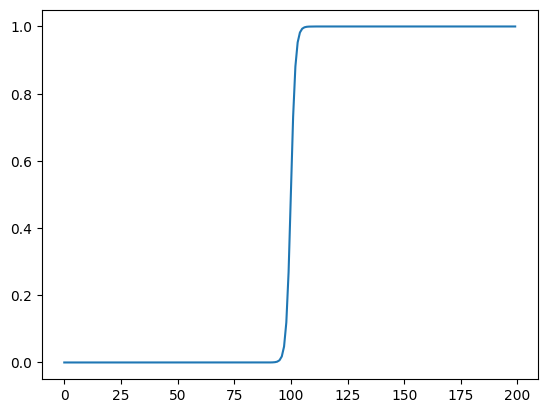

In [36]:
p.plot(res)

In [37]:
def gradientDescent(x, y, theta, alpha, num_iters):
    m = x.shape[0]

    # Переконаємося, що y має правильну форму (m,1)
    if y.ndim == 1:
        y = y.reshape(-1, 1)

    for i in range(0, num_iters):
        # Обчислюємо гіпотезу
        z = np.dot(x, theta)
        h = sigmoid(z)

        # Обчислюємо функцію втрат - скалярне значення
        # Використовуємо поелементне множення і сумування
        epsilon = 1e-15  # Маленька константа для уникнення log(0)
        h_safe = np.clip(h, epsilon, 1 - epsilon)
        J = (-1/m) * np.sum(y * np.log(h_safe) + (1-y) * np.log(1 - h_safe))

        # Оновлюємо параметри
        theta = theta - (alpha/m) * np.dot(x.T, (h-y))

        # Виводимо значення помилки (опціонально)
        if i % 10 == 0:
            print(i, J)

    return J, theta

In [38]:
def extract_features(sentence, freqs):
    word_l = process_sentence(sentence)
    x = np.zeros((1, 3))
    x[0,0] = 1
    for word in word_l:
        if (word, 1.0) in freqs:
            x[0,1] += freqs[(word, 1.0)]
        if (word, 0.0) in freqs:
            x[0,2] += freqs[(word, 0.0)]
    return x

In [39]:
def predict_sentence(sentence, freqs, theta):
    x = extract_features(sentence, freqs)
    y_pred = sigmoid(np.dot(x, theta))
    return y_pred

In [40]:
freqs

{('rock', 1.0): 12,
 ('destin', 1.0): 8,
 ('21st', 1.0): 2,
 ("century'", 1.0): 1,
 ('new', 1.0): 87,
 ('conan', 1.0): 2,
 ('go', 1.0): 70,
 ('make', 1.0): 255,
 ('splash', 1.0): 3,
 ('even', 1.0): 145,
 ('greater', 1.0): 4,
 ('arnold', 1.0): 3,
 ('schwarzenegg', 1.0): 2,
 ('jean-claud', 1.0): 1,
 ('van', 1.0): 3,
 ('damm', 1.0): 1,
 ('steven', 1.0): 13,
 ('segal', 1.0): 1,
 ('gorgeous', 1.0): 4,
 ('elabor', 1.0): 3,
 ('continu', 1.0): 11,
 ('lord', 1.0): 2,
 ('ring', 1.0): 9,
 ('trilog', 1.0): 3,
 ('huge', 1.0): 12,
 ('column', 1.0): 1,
 ('word', 1.0): 18,
 ('cannot', 1.0): 8,
 ('adequ', 1.0): 4,
 ('describ', 1.0): 3,
 ('co-writ', 1.0): 6,
 ('director', 1.0): 113,
 ('peter', 1.0): 7,
 ("jackson'", 1.0): 2,
 ('expand', 1.0): 4,
 ('vision', 1.0): 16,
 ('j', 1.0): 7,
 ('r', 1.0): 3,
 ("tolkien'", 1.0): 2,
 ('middle-earth', 1.0): 1,
 ('effect', 1.0): 49,
 ('too-tepid', 1.0): 1,
 ('biopic', 1.0): 4,
 ('sometim', 1.0): 32,
 ('like', 1.0): 230,
 ('movi', 1.0): 469,
 ('fun', 1.0): 90,
 ('wasa

In [41]:
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :] = extract_features(train_x[i], freqs)

In [42]:
X.shape

(8000, 3)

In [43]:
X[7995:]

array([[  1., 895., 728.],
       [  1., 481., 452.],
       [  1., 611., 786.],
       [  1., 572., 574.],
       [  1., 178., 287.]])

In [44]:
train_x[7995:]

['a nearly 21/2 hours , the film is way too indulgent . ',
 'gorgeous to look at but insufferably tedious and turgid . . . a curiously constricted epic . ',
 'it looks much more like a cartoon in the end than the simpsons ever has . ',
 'with a tighter editorial process and firmer direction this material could work , especially since the actresses in the lead roles are all more than competent , but as is , personal velocity seems to be idling in neutral . ',
 "doesn't really add up to much . "]

In [45]:
Y = train_y.reshape(-1, 1)

In [46]:
Y.shape

(8000, 1)

Пояснення до п. 9: шляхом зміни швидкості навчання та кількості ітерацій були виявлені оптимальні параметри: 1e-3 для швидкості навчання, 1250 для кількості ітерацій. Якщо далі збільшувати швидкість навчання (наприклад, 0.01), то помилка зростає.

In [58]:
J, theta = gradientDescent(X, Y, np.zeros((3, 1)), 1e-3, 1250)
print(f"Помилка після навчання: {J:.8f}.")
print(f"Вектор вагових коефіцієнтів: {[round(t, 8) for t in np.squeeze(theta)]}")

0 0.6931471805599454
10 12.384381255134482
20 12.435527692601678
30 13.452209857950196
40 13.654015751468975
50 13.13050859179397
60 12.434391525450922
70 11.431478085411303
80 10.621398508425411
90 10.381530513404998
100 10.619939124177055
110 10.491362011744965
120 10.516867326748363
130 10.531985933038554
140 10.504004510909642
150 10.526738058208686
160 10.515381501842487
170 10.516505272873747
180 10.520212438271155
190 10.515626690958134
200 10.518884340530983
210 10.517455157156972
220 10.51738715400589
230 10.51812093829623
240 10.51734616773184
250 10.517827281923743
260 10.517632777771352
270 10.517573814122409
280 10.51771212442955
290 10.517577178281275
300 10.517629542562586
310 10.517607266056102
320 10.517589017020669
330 10.5176016011938
340 10.517579249393854
350 10.517580175435748
360 10.517572038355947
370 10.517563350237292
380 10.517562069271579
390 10.51755236648642
400 10.517546616428643
410 10.517539740377057
420 10.51753147849862
430 10.517525182029168
440 10.5

/tmp/ipykernel_2449/4005796728.py:2: RuntimeWarning: overflow encountered in exp
  h = 1 / (1 + np.exp(-z))


1000 10.517105646429641
1010 10.517103295510628
1020 10.517096361483079
1030 10.517090154208644
1040 10.517083585154896
1050 10.517077206377012
1060 10.517070421949496
1070 10.517060639401722
1080 10.517053923761015
1090 10.517047571482898
1100 10.517040243269836
1110 10.517030762920156
1120 10.517023684233278
1130 10.517018597205078
1140 10.517011952887916
1150 10.517005361070105
1160 10.516999502217688
1170 10.517000331221123
1180 10.516993209489247
1190 10.51698518840453
1200 10.516977954804533
1210 10.516971253789759
1220 10.516963775067822
1230 10.516956737131453
1240 10.516949991025887
Помилка після навчання: 9.52105172.
Вектор вагових коефіцієнтів: [np.float64(-0.02293684), np.float64(0.85910808), np.float64(-0.66179039)]


In [66]:
sentence = " ".join(neg_sentences[0])
sentence

'simplistic , silly and tedious .'

In [67]:
if predict_sentence(sentence, freqs, theta) >= 0.5:
    print("позитив")
else:
    print("негатив")

негатив


In [68]:
def test_logistic_regression(test_x, test_y, freqs, theta):
    y_hat = []
    for sentence in test_x:
        # Якщо елемент у test_x є списком слів, об'єднуємо його у рядок перед прогнозом
        if isinstance(sentence, list):
            sentence = " ".join(sentence)

        y_pred = predict_sentence(sentence, freqs, theta)
        if y_pred > 0.5:
            y_hat.append(1)
        else:
            y_hat.append(0)

    accuracy = (np.sum(np.array(y_hat) == np.squeeze(test_y))) / len(test_x)
    return accuracy

tmp_accuracy = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Точність логістичної регресії: {tmp_accuracy:.4f}")

Точність логістичної регресії: 0.6146


In [72]:
test_msg = "A wonderful movie with brilliant acting, a fantastic storyline, and deeply moving emotional scenes."

p = predict_sentence(test_msg, freqs, theta)
if p > 0.65:
    print("позитив", p)
else:
    print("негатив", p)

позитив [[1.]]


In [70]:
test_msg = "This film has incredible acting and a brilliant storyline, making it an absolute masterpiece of cinema."

p = predict_sentence(test_msg, freqs, theta)
if p > 0.65:
    print("позитив", p)
else:
    print("негатив", p)

позитив [[1.]]


In [71]:
my_sentence = "terrible plot and extremely boring actors"

print(process_sentence(my_sentence))
y_hat = predict_sentence(my_sentence, freqs, theta)
print(y_hat)

if y_hat > 0.5:
    print('Позитивна тональність')
else:
    print('Негативна тональність')

['terribl', 'plot', 'extrem', 'bore', 'actor']
[[9.9249677e-32]]
Негативна тональність


In [73]:
result = [freqs, theta]

In [74]:
type(freqs)

dict